Make a subset of the GSS data set from this link:

https://sda.berkeley.edu/sdaweb/analysis/?dataset=gss24rel1


In [333]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [334]:
df = pd.read_csv("gss_qol.csv")
df.head(5)

/var/folders/nx/y262pp8d4dzf82b2kl0f_g340000gn/T/ipykernel_41961/2229158646.py:1: DtypeWarning: Columns (3,4,50,54,78,79,80,89,90) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("gss_qol.csv")


,year,id,age,sex,race,hispanic,ethnic,spethnic,uscitzn,educ,...,world2,world3,world4,world5,world6,world7,happy,hapmar,health,life
0,1972,1,23,2,1,.y,.u,.u,.y,16,...,.i,.i,.i,.i,.i,.i,3,.i,2,.i
1,1972,2,70,1,1,.y,14,.u,.y,10,...,.i,.i,.i,.i,.i,.i,3,.i,3,.i
2,1972,3,48,2,1,.y,15,.u,.y,12,...,.i,.i,.i,.i,.i,.i,2,.i,1,.i
3,1972,4,27,2,1,.y,37,.u,.y,17,...,.i,.i,.i,.i,.i,.i,3,.i,2,.i
4,1972,5,61,2,1,.y,27,.u,.y,12,...,.i,.i,.i,.i,.i,.i,2,.i,2,.i


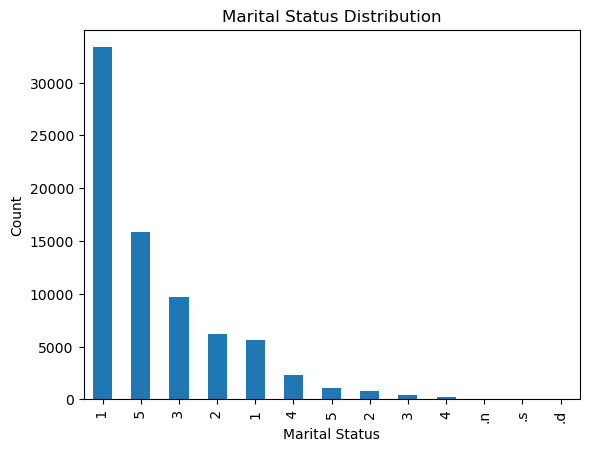

In [335]:
# how many values of each unique answer in marital column
# bar plot
df['marital'].value_counts().plot(kind='bar')
plt.title('Marital Status Distribution')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.show()

Need to fix missing values:
   - .d: Don't know 
   - .i: Inapplicable (often means the question wasn't asked of that person) 
   - .n: No answer 
   - .y: Not available in this year

In [336]:
df['hapmar'].unique()

array(['.i', ' 1', ' 2', ' 3', '.n', '.d', '.s'], dtype=object)

In [337]:
df['happy'].unique()

array([' 3', ' 2', ' 1', '.n', '.d', '.i', '.s'], dtype=object)

In [338]:
gss_na_codes = ['.d', '.i', '.j', '.m', '.n', '.p', '.r', '.s', '.u', '.x', '.y', '.z']
qol = pd.read_csv('gss_qol.csv')

# dont map to specific columns, hapmar, agewed, divorce, widowed should be left as is because they have structural missingness that we want to keep as np.nan
cols_to_exclude = ['hapmar', 'agewed', 'divorce', 'widowed']

# Comprehensive mapping dictionary derived from the GSS 1972-2024 Codebook 
# Note: Variables like 'year', 'id', and 'age' are kept as numeric [cite: 311, 314, 315]
variable_mappings = {
    'sex': {1: 'male', 2: 'female'}, # [cite: 319]
    'race': {1: 'white', 2: 'black', 3: 'other'}, # [cite: 324]
    'hispanic': {
        1: 'not hispanic', 2: 'mexican, mexican american, chicano/a', 
        3: 'puerto rican', 4: 'cuban', 5: 'another hispanic, latino, or spanish origin'
    }, # [cite: 334]
    'uscitzn': {1: 'a u.s. citizen', 2: 'not a u.s. citizen'}, # [cite: 348, 349]
    'degree': {
        0: 'less than high school', 1: 'high school', 
        2: 'associate/junior college', 3: "bachelor's", 4: 'graduate'
    }, # [cite: 375]
    'padeg': {
        0: 'less than high school', 1: 'high school', 
        2: 'associate/junior college', 3: "bachelor's", 4: 'graduate'
    }, # [cite: 379, 380]
    'madeg': {
        0: 'less than high school', 1: 'high school', 
        2: 'associate/junior college', 3: "bachelor's", 4: 'graduate'
    }, # [cite: 384]
    'spdeg': {
        0: 'less than high school', 1: 'high school', 
        2: 'associate/junior college', 3: "bachelor's", 4: 'graduate'
    }, # [cite: 388, 389]
    'voedcol': {1: 'yes', 2: 'no'}, # [cite: 403]
    'voedncol': {1: 'yes', 2: 'no'}, # [cite: 408]
    'dipged': {
        1: 'high school diploma', 2: 'ged', 3: 'other', 
        5: 'high school diploma after post high school class'
    }, # [cite: 62]
    'spdipged': {
        1: 'high school diploma', 2: 'ged', 3: 'other', 
        5: 'high school diploma after post high school class'
    }, # [cite: 64]
    'hapcohab': {1: 'very happy', 2: 'pretty happy', 3: 'not too happy'}, # 
    'convictd': {1: 'yes', 2: 'no'}, # [cite: 76]
    'lockedup': {1: 'yes', 2: 'no'}, # [cite: 77]
    'workdy': {
        1: 'mon to fri', 2: 'mon to fri,sat', 3: 'mon to fri,sun', 
        4: 'wkend plus', 5: 'no schedule'
    }, # [cite: 78]
    'workhr': {1: 'reg day', 2: 'eve', 3: 'nights', 4: 'varies', 5: 'other'}, # [cite: 79]
    'spdays': {
        1: 'mon to fri', 2: 'mon to fri,sat', 3: 'mon to fri,sun', 
        4: 'wkend plus', 5: 'no schedule'
    }, # [cite: 80]
    'sphour': {1: 'reg day', 2: 'eve', 3: 'nights', 4: 'varies', 5: 'other'}, # [cite: 81]
    'happy': {1: 'very happy', 2: 'pretty happy', 3: 'not too happy'},  # 
    'health': {1: 'excellent', 2: 'good', 3: 'fair', 4: 'poor'}, # [cite: 309]
    #'life': {1: 'exciting', 2: 'routine', 3: 'dull'} # [cite: 310]
}

# Apply the mappings to all columns in the dataframe
# This will only replace values in columns found in the dictionary
variable_mappings = {col: mapping for col, mapping in variable_mappings.items() if col not in cols_to_exclude}
for col in qol.columns:
    if col not in cols_to_exclude:
        qol[col] = qol[col].replace(gss_na_codes, pd.NA)

for col, mapping in variable_mappings.items():
    if col in qol.columns:
        # Convert numeric strings to integers (errors become NaN)
        qol[col] = pd.to_numeric(qol[col], errors='coerce')
        # Then map
        qol[col] = qol[col].map(mapping)

qol.head(5)

/var/folders/nx/y262pp8d4dzf82b2kl0f_g340000gn/T/ipykernel_41961/1995061763.py:2: DtypeWarning: Columns (3,4,50,54,78,79,80,89,90) have mixed types. Specify dtype option on import or set low_memory=False.
  qol = pd.read_csv('gss_qol.csv')


,year,id,age,sex,race,hispanic,ethnic,spethnic,uscitzn,educ,...,world2,world3,world4,world5,world6,world7,happy,hapmar,health,life
0,1972,1,23,female,white,NaN,.u,<NA>,NaN,16,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,not too happy,.i,good,<NA>
1,1972,2,70,male,white,NaN,14,<NA>,NaN,10,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,not too happy,.i,fair,<NA>
2,1972,3,48,female,white,NaN,15,<NA>,NaN,12,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,pretty happy,.i,excellent,<NA>
3,1972,4,27,female,white,NaN,37,<NA>,NaN,17,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,not too happy,.i,good,<NA>
4,1972,5,61,female,white,NaN,27,<NA>,NaN,12,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,pretty happy,.i,good,<NA>


In [339]:
print("Hapmar values:")
print(qol['hapmar'].unique())
print("Agewed values:")
print(qol['agewed'].unique())
print("Divorce values:")
print(qol['divorce'].unique())
print("Widowed values:")
print(qol['widowed'].unique())

Hapmar values:
['.i' ' 1' ' 2' ' 3' '.n' '.d' '.s']
Agewed values:
['.i' '21' '20' '24' '22' '19' '25' '17' '18' '16' '26' '30' '15' '37'
 '23' '35' '28' '29' '27' '43' '38' '14' '13' '31' '32' '33' '39' '.n'
 '36' '42' '40' '45' '46' '34' '58' '48' '55' '52' '63' '44' '41' '60'
 '51' '49' '12' '50' '73' '.d' '47' '56' '62' '68' '54' '61' '53' '57'
 '59' '70' '90' '65' '.y']
Divorce values:
['.i' ' 2' ' 1' '.n' '.d' '.s']
Widowed values:
['.i' ' 2' '.n' ' 1' '.d' '.s']


In [340]:
qol['happy'].unique()

array(['not too happy', 'pretty happy', 'very happy', nan], dtype=object)

In [341]:
## for hapmar, agewed, divorce, widowed, we want to keep the structural missingness as np.nan, so we will not map those columns to categorical values. Instead, we will just keep them as numeric values where 1 = yes and 2 = no, and any .i values will be replaced with np.nan to indicate structural missingness.
# hapmar = happily married. NA if never married
# agewed = age at first marriage. NA if never married
# divorce = ever divorced. NA if never married
# widowed = ever widowed. NA if never married

#hapmar, drop values that are not .i, 1, 2, 3
excluded_cols_na_codes = ['.d', '.j', '.m', '.n', '.p', '.r', '.s', '.u', '.x', '.y', '.z']
for col in cols_to_exclude:
    qol[col] = qol[col].replace(excluded_cols_na_codes, pd.NA)

In [342]:
## unique values for hapmar, agewed, divorce, widowed after cleaning
print("Hapmar values after cleaning:")
print(qol['hapmar'].unique())
print("Agewed values after cleaning:")
print(qol['agewed'].unique())
print("Divorce values after cleaning:")
print(qol['divorce'].unique())
print("Widowed values after cleaning:")
print(qol['widowed'].unique())

Hapmar values after cleaning:
['.i' ' 1' ' 2' ' 3' <NA>]
Agewed values after cleaning:
['.i' '21' '20' '24' '22' '19' '25' '17' '18' '16' '26' '30' '15' '37'
 '23' '35' '28' '29' '27' '43' '38' '14' '13' '31' '32' '33' '39' <NA>
 '36' '42' '40' '45' '46' '34' '58' '48' '55' '52' '63' '44' '41' '60'
 '51' '49' '12' '50' '73' '47' '56' '62' '68' '54' '61' '53' '57' '59'
 '70' '90' '65']
Divorce values after cleaning:
['.i' ' 2' ' 1' <NA>]
Widowed values after cleaning:
['.i' ' 2' <NA> ' 1']


In [343]:
#qol.to_csv("clean_qol.csv")

In [344]:
keep = ['year', 'id', 'age', 'sex', 'race', 'degree', 'educ', 'relig', 'marital', 'agewed', 'divorce', 'widowed', 'wrkstat', 'happy', 'hapmar', 'health', 'life']
smol_qol = qol[keep]
smol_qol = smol_qol.dropna()
#smol_qol.to_csv("smaller_qol.csv")

In [345]:
## make all values in workstat numeric (values already numbers just as strings)
smol_qol['wrkstat'] = pd.to_numeric(smol_qol['wrkstat'], errors='coerce')

In [346]:
## check unique values from every column in smaller_qol
for col in smol_qol.columns:
    print(f"Unique values in column '{col}': {smol_qol[col].unique()}")

Unique values in column 'year': [1973 1974 1976 1977 1980 1982 1984 1985 1987 1988 1989 1990 1991 1993
 1994 1996 1998 2000 2002 2004 2006 2008 2010 2012 2014 2016 2018 2021]
Unique values in column 'id': [   1    2    3 ... 4464 4466 4467]
Unique values in column 'age': ['54' '51' '36' '32' '41' '31' '26' '78' '46' '67' '39' '76' '34' '35'
 '55' '44' '40' '57' '68' '62' '72' '25' '69' '38' '56' '20' '66' '43'
 '37' '49' '53' '79' '27' '30' '22' '50' '58' '85' '77' '45' '19' '24'
 '21' '71' '74' '33' '52' '28' '63' '47' '42' '60' '59' '29' '70' '75'
 '48' '23' '83' '65' '64' '61' '82' '73' '89' '86' '18' '81' '80' '88'
 '84' '87']
Unique values in column 'sex': ['male' 'female']
Unique values in column 'race': ['white' 'black' 'other']
Unique values in column 'degree': ['less than high school' 'high school' "bachelor's" 'graduate'
 'associate/junior college']
Unique values in column 'educ': [' 6' ' 8' '11' '12' '16' ' 7' '14' '13' ' 4' '10' '15' '18' ' 9' '19'
 '17' '20' ' 3' ' 0' ' 5'

In [347]:
## NAs for each column
smol_qol.isna().sum()

year       0
id         0
age        0
sex        0
race       0
degree     0
educ       0
relig      0
marital    0
agewed     0
divorce    0
widowed    0
wrkstat    0
happy      0
hapmar     0
health     0
life       0
dtype: int64

In [348]:
## turn ".i" into np.nan for all columns in smol_qol
for col in smol_qol.columns:
    smol_qol[col] = smol_qol[col].replace('.i', pd.NA)

In [349]:
## unique values in wid column
smol_qol['widowed'].unique()

array([<NA>, ' 2', ' 1'], dtype=object)

In [350]:
## turn agewed, divorce, widowed, and hapmar into numeric and keep NAs
for col in ['agewed', 'divorce', 'widowed', 'hapmar']:
    smol_qol[col] = pd.to_numeric(smol_qol[col], errors='coerce')

In [351]:
## unique values in wid column
smol_qol['widowed'].unique()

array([nan,  2.,  1.])

In [352]:
smol_qol['life'].unique()

array([' 2', ' 1', ' 3'], dtype=object)

In [353]:
## missing values in smol_qol
smol_qol.isna().sum()

year           0
id             0
age            0
sex            0
race           0
degree         0
educ           0
relig          0
marital        0
agewed     24578
divorce    15509
widowed    21472
wrkstat        0
happy          0
hapmar     19354
health         0
life           0
dtype: int64

In [354]:
smol_qol.head(5)

,year,id,age,sex,race,degree,educ,relig,marital,agewed,divorce,widowed,wrkstat,happy,hapmar,health,life
1613,1973,1,54,male,white,less than high school,6,1,1,29.0,2.0,NaN,1,not too happy,1.0,fair,2
1614,1973,2,51,female,white,less than high school,8,1,1,21.0,2.0,NaN,7,very happy,1.0,good,2
1615,1973,3,36,female,white,less than high school,11,1,1,17.0,2.0,NaN,1,pretty happy,1.0,excellent,2
1616,1973,4,32,male,white,high school,12,1,1,27.0,2.0,NaN,1,pretty happy,1.0,excellent,2
1617,1973,5,54,female,white,less than high school,8,1,1,18.0,2.0,NaN,7,pretty happy,2.0,good,2


In [355]:
# 1. Define the mapping dictionaries
health_map = {'excellent': 4, 'good': 3, 'fair': 2, 'poor': 1}
sex_map    = {'male': 0, 'female': 1}
happy_map  = {'pretty happy': 1, 'very happy': 2, 'not too happy': 0}
degree_map = {
    'less than high school': 0, 'high school': 1, 
    'associate/junior college': 2, "bachelor's": 3, 'graduate': 4
}
race_map = {'white': 0, 'black': 1, 'other': 2}

# 2. Apply the maps
smol_qol['health_new'] = smol_qol['health'].map(health_map)
smol_qol['sex_new']    = smol_qol['sex'].map(sex_map)
smol_qol['happy_new']  = smol_qol['happy'].map(happy_map)
smol_qol['degree_new'] = smol_qol['degree'].map(degree_map)
smol_qol['race_new']   = smol_qol['race'].map(race_map)

## turn life into numeric (values already numbers just as strings)
smol_qol['life_new'] = pd.to_numeric(smol_qol['life'], errors='coerce')

In [356]:
smol_qol['life_new'].unique()

array([2, 1, 3])

In [357]:
smol_qol.head(5)

,year,id,age,sex,race,degree,educ,relig,marital,agewed,...,happy,hapmar,health,life,health_new,sex_new,happy_new,degree_new,race_new,life_new
1613,1973,1,54,male,white,less than high school,6,1,1,29.0,...,not too happy,1.0,fair,2,2,0,0,0,0,2
1614,1973,2,51,female,white,less than high school,8,1,1,21.0,...,very happy,1.0,good,2,3,1,2,0,0,2
1615,1973,3,36,female,white,less than high school,11,1,1,17.0,...,pretty happy,1.0,excellent,2,4,1,1,0,0,2
1616,1973,4,32,male,white,high school,12,1,1,27.0,...,pretty happy,1.0,excellent,2,4,0,1,1,0,2
1617,1973,5,54,female,white,less than high school,8,1,1,18.0,...,pretty happy,2.0,good,2,3,1,1,0,0,2


In [360]:
## keep only the numeric columns for modeling
numeric_cols = ['year', 'id', 'age', 'sex_new', 'race_new', 'degree_new', 'educ', 'relig', 'marital', 'agewed', 'divorce', 'widowed', 'wrkstat', 'happy_new', 'hapmar','health_new', 'life_new']

In [361]:
## count NAs and report final shape
final_qol = smol_qol[numeric_cols]
print("Final shape of the dataset:", final_qol.shape)
print("Number of missing values in each column:")
print(final_qol.isna().sum())

Final shape of the dataset: (40353, 17)
Number of missing values in each column:
year              0
id                0
age               0
sex_new           0
race_new          0
degree_new        0
educ              0
relig             0
marital           0
agewed        24578
divorce       15509
widowed       21472
wrkstat           0
happy_new         0
hapmar        19354
health_new        0
life_new          0
dtype: int64


In [362]:
## SAVE FINAL DATASET
final_qol.to_csv("ACTUAL_qol.csv", index=False)

In [ ]:
# 1. Define the mapping dictionaries
# health_map = {'excellent': 4, 'good': 3, 'fair': 2, 'poor': 1}
# life_map   = {'exciting': 3, 'routine': 2, 'dull': 1}
# sex_map    = {'male': 0, 'female': 1}
# happy_map  = {'pretty happy': 1, 'very happy': 2, 'not too happy': 0}

# # 2. Apply the maps
# df2['health_new'] = df2['health'].map(health_map)
# df2['life_new']   = df2['life'].map(life_map)
# df2['sex_new']    = df2['sex'].map(sex_map)
# df2['happy_new']  = df2['happy'].map(happy_map)

# df_new = df2[['year', 'age', 'sex_new', 'race', 'degree', 'educ', 'relig', 'marital', 'wrkstat', 'occ', 'happy_new', 'health_new', 'life_new']]
# ## drop rows that have missing age, sex, race, degree, educ, religion, marital, happy, life, health
# df_new = df_new.dropna(subset=['age', 'degree', 'educ', 'relig', 'marital', 'wrkstat', 'health_new', 'life_new'])
# print(df_new.isnull().sum())
# print(df_new.shape[0])
# df_new.to_csv("qol.csv")

year          0
age           0
sex_new       0
race          0
degree        0
educ          0
relig         0
marital       0
wrkstat       0
occ           0
happy_new     0
health_new    0
life_new      0
dtype: int64
43158
